In [10]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from plotly import graph_objs as go

from src.green_gecko_model import CAModel, make_seed

In [11]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

# Whether to scale the attractor or not
scale_attractor = True

In [12]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model2/crab/seed_a/8000.weights.h5")
None

In [13]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(3000): # It's supposed to be 3000
    x = model(x)
    states.append(tf.identity(x).numpy())

In [14]:
states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] #[:,:,10:-10,10:-10]
print(states_np.shape)
x_star = states_np[-1,0]
print(x_star.shape)

(3001, 1, 40, 40, 16)
(40, 40, 16)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037648782..1.0549058].


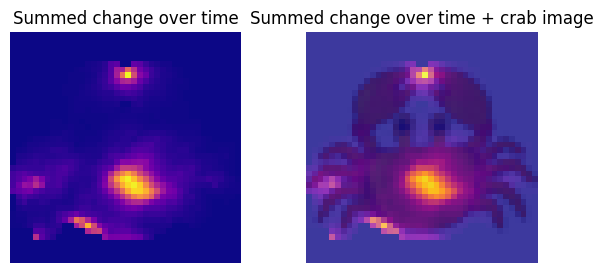

In [15]:
# States_np has shape (Timesteps, batch=1, height, width, channels)
start_time = 2000
diff = states_np[start_time+1:, 0] - states_np[start_time:-1, 0]
diff_abs = np.abs(diff)
diff_sum_channels = np.sum(diff_abs, axis=(0))
diff_sum_all = np.sum(diff_abs, axis=(0,-1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
ax1.imshow(diff_sum_all, cmap='plasma')
ax1.set_title("Summed change over time")
ax1.axis('off')
ax2.imshow(x_star[:,:,:4], alpha=1)
ax2.imshow(diff_sum_all, cmap='plasma', alpha=0.8)
ax2.set_title("Summed change over time + crab image")
ax2.axis('off')
plt.savefig('diff_sum.svg')

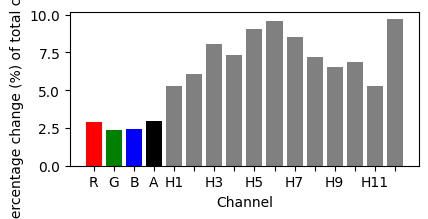

In [16]:
# Show a bar plot showing difference per channel
fig, ax = plt.subplots(figsize=(4.5, 2))
ax.bar(range(CHANNEL_N), diff_sum_channels.sum(axis=(0,1)) *100/ diff_sum_channels.sum())
lables = ["R", "G", "B", "A", "H1", "", "H3", "", "H5", "", "H7", "", "H9", "", "H11", ""]
ax.set_xticks(range(CHANNEL_N), lables)
# Set colors for each bar

# Set colors for each bar
colors = ['red', 'green', 'blue', 'black', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', ]
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(colors[i % len(colors)])

ax.set_xlabel('Channel')
ax.set_ylabel('Percentage change (%) of total change')
plt.savefig('diff_bar_crab.svg')

In [17]:
import matplotlib.animation as animation

diff_abs_all = np.sum(diff_abs, axis=(-1))[0:300]

fig, ax = plt.subplots()
im = ax.imshow(diff_abs_all[0], animated=True, cmap='hot')
plt.colorbar(im)
title = ax.set_title('t=0')

im.set_clim(0, diff_abs_all.max())

def update(t):
    im.set_array(diff_abs_all[t])
    
    title.set_text(f't={t}')
    return im, title

ani = animation.FuncAnimation(fig, update, frames=len(diff_abs_all), interval=50, blit=True)
ani.save('diff_video.gif', writer='pillow', fps=20)
plt.close()

In [18]:
"""import matplotlib.animation as animation
import math

diff_abs_short = diff_abs[-200:]
n_channels = diff_abs_short.shape[-1]

# make a grid, e.g. 4x4 for 16 channels
n_cols = 4
n_rows = math.ceil(n_channels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

# global color limit across all channels
vmax = diff_abs_short.max()

ims = []
for c in range(n_channels):
    im = axes[c].imshow(diff_abs_short[0, :, :, c], cmap='hot', vmin=0, vmax=vmax, animated=True)
    axes[c].set_title(f'ch {c}')
    axes[c].axis('off')
    ims.append(im)

# hide unused axes if n_channels isn't divisible by n_cols
for c in range(n_channels, len(axes)):
    axes[c].set_visible(False)

title = fig.suptitle('t=0')

def update(t):
    for c in range(n_channels):
        ims[c].set_array(diff_abs_short[t, :, :, c])
    title.set_text(f't={t}')
    return ims + [title]

ani = animation.FuncAnimation(fig, update, frames=len(diff_abs_short), interval=50, blit=True)
plt.tight_layout()
ani.save('diff_video_channels.gif', writer='pillow', fps=20)
plt.close()"""

"import matplotlib.animation as animation\nimport math\n\ndiff_abs_short = diff_abs[-200:]\nn_channels = diff_abs_short.shape[-1]\n\n# make a grid, e.g. 4x4 for 16 channels\nn_cols = 4\nn_rows = math.ceil(n_channels / n_cols)\n\nfig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))\naxes = axes.flatten()\n\n# global color limit across all channels\nvmax = diff_abs_short.max()\n\nims = []\nfor c in range(n_channels):\n    im = axes[c].imshow(diff_abs_short[0, :, :, c], cmap='hot', vmin=0, vmax=vmax, animated=True)\n    axes[c].set_title(f'ch {c}')\n    axes[c].axis('off')\n    ims.append(im)\n\n# hide unused axes if n_channels isn't divisible by n_cols\nfor c in range(n_channels, len(axes)):\n    axes[c].set_visible(False)\n\ntitle = fig.suptitle('t=0')\n\ndef update(t):\n    for c in range(n_channels):\n        ims[c].set_array(diff_abs_short[t, :, :, c])\n    title.set_text(f't={t}')\n    return ims + [title]\n\nani = animation.FuncAnimation(fig, update, frames=le